<a href="https://colab.research.google.com/github/nguyenthientan321-debug/pollution/blob/main/B%C3%A0i_ti%E1%BB%83u_lu%E1%BA%ADn_code_nh%E1%BA%ADp_m%C3%B4n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from os import path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
path = '/content/drive/MyDrive/diabetes.csv'
df = pd.read_csv(path)


In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.shape

(768, 9)

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [ ]:
(df == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [ ]:
#Kiểm tra cột 'Outcome'
print("Phân bổ cột Outcome:")
print(df['Outcome'].value_counts())

#Kiểm tra cột 'Pregnancies' (Số lần mang thai)
print("\nPhân bổ cột Pregnancies:")
print(df['Pregnancies'].value_counts().sort_index()) # .sort_index() để xếp theo thứ tự

Phân bổ cột Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64

Phân bổ cột Pregnancies:
Pregnancies
0     111
1     135
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
12      9
13     10
14      2
15      1
17      1
Name: count, dtype: int64


In [ ]:
# 2. Xác định các cột có giá trị 0 bất thường
cols_with_zero_errors = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

In [ ]:
# 3. Thay thế các giá trị 0 bất thường bằng NaN (Not a Number)
# Dùng .loc[:, ...] để gán lại trực tiếp vào DataFrame
df.loc[:, cols_with_zero_errors] = df[cols_with_zero_errors].replace(0, np.nan)

print("\n--- Số lượng giá trị thiếu (NaN) SAU KHI thay thế 0 ---")
print(df.isnull().sum())
print("-" * 40)


--- Số lượng giá trị thiếu (NaN) SAU KHI thay thế 0 ---
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
----------------------------------------


/tmp/ipython-input-1833951348.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[148.  85. 183.  89. 137. 116.  78. 115. 197. 125. 110. 168. 139. 189.
 166. 100. 118. 107. 103. 115. 126.  99. 196. 119. 143. 125. 147.  97.
 145. 117. 109. 158.  88.  92. 122. 103. 138. 102.  90. 111. 180. 133.
 106. 171. 159. 180. 146.  71. 103. 105. 103. 101.  88. 176. 150.  73.
 187. 100. 146. 105.  84. 133.  44. 141. 114.  99. 109. 109.  95. 146.
 100. 139. 126. 129.  79.  nan  62.  95. 131. 112. 113.  74.  83. 101.
 137. 110. 106. 100. 136. 107.  80. 123.  81. 134. 142. 144.  92.  71.
  93. 122. 163. 151. 125.  81.  85. 126.  96. 144.  83.  95. 171. 155.
  89.  76. 160. 146. 124.  78.  97.  99. 162. 111. 107. 132. 113.  88.
 120. 118. 117. 105. 173. 122. 170.  84.  96. 125. 100.  93. 129. 105.
 128. 106. 108. 108. 154. 102.  57. 106. 147.  90. 136. 114. 156. 153.
 188. 152.  99. 109.  88. 163. 151. 102. 114. 100. 131. 104. 148.

In [ ]:
# 4. Điền (chèn) các giá trị thiếu (NaN) bằng giá trị TRUNG VỊ (median)
# (Chúng ta dùng trung vị vì nó ít bị ảnh hưởng bởi giá trị ngoại lai)
for col in cols_with_zero_errors:
    # Tính giá trị trung vị của cột (bỏ qua các giá trị NaN)
    median_val = df[col].median()

    # Điền giá trị trung vị vào các ô bị thiếu (NaN)
    df[col] = df[col].fillna(median_val)

    print(f"Đã điền giá trị thiếu cho cột '{col}' bằng trung vị: {median_val}")

print("\n--- Đã xử lý xong! Kiểm tra lại số lượng NaN (thiếu): ---")
print(df.isnull().sum())

print("\n--- Thống kê của dữ liệu đã xử lý (để thấy min đã thay đổi): ---")
print(df.describe())

Đã điền giá trị thiếu cho cột 'Glucose' bằng trung vị: 117.0
Đã điền giá trị thiếu cho cột 'BloodPressure' bằng trung vị: 72.0
Đã điền giá trị thiếu cho cột 'SkinThickness' bằng trung vị: 29.0
Đã điền giá trị thiếu cho cột 'Insulin' bằng trung vị: 125.0
Đã điền giá trị thiếu cho cột 'BMI' bằng trung vị: 32.3

--- Đã xử lý xong! Kiểm tra lại số lượng NaN (thiếu): ---
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

--- Thống kê của dữ liệu đã xử lý (để thấy min đã thay đổi): ---
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.656250      72.386719      29.108073  140.671875   
std       3.369578   30.438286      12.096642       8.

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


In [ ]:
sns.set_theme(style="dark")

In [ ]:
# Các thư viện xử lý dữ liệu
import pandas as pd
import numpy as np

# Các thư viện vẽ đồ thị
import seaborn as sns
import matplotlib.pyplot as plt

# Các thư viện Học máy (Machine Learning)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# --- BƯỚC: CHIA VÀ CHUẨN HÓA DỮ LIỆU ---

# 1. Import thư viện cần thiết
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2. Tách đặc trưng (X) và nhãn mục tiêu (y)
X = df.drop('Outcome', axis=1)  # Lấy tất cả các cột trừ 'Outcome'
y = df['Outcome']               # Chỉ lấy cột 'Outcome'

# 3. Chia dữ liệu thành tập Huấn luyện (Train) và Kiểm tra (Test)
# - test_size=0.2: Dành 20% dữ liệu để kiểm tra
# - random_state=42: Để kết quả chia giống nhau mỗi lần chạy
# - stratify=y: Giữ nguyên tỷ lệ bệnh/không bệnh ở cả 2 tập
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Chuẩn hóa dữ liệu (Scaling)
# - Mục đích: Đưa các cột về cùng một thang đo (quan trọng cho Logistic Regression)
scaler = StandardScaler()

# "Học" thang đo từ tập Train và biến đổi nó
X_train_scaled = scaler.fit_transform(X_train)

# Áp dụng thang đo đã học vào tập Test (Lưu ý: Chỉ dùng .transform, KHÔNG dùng .fit)
X_test_scaled = scaler.transform(X_test)

# 5. Kiểm tra kết quả
print("✅ Đã chia và chuẩn hóa xong!")
print(f"- Kích thước tập Train: {X_train_scaled.shape}")
print(f"- Kích thước tập Test:  {X_test_scaled.shape}")
print("\n5 dòng đầu của dữ liệu sau khi chuẩn hóa (X_train_scaled):")
print(X_train_scaled[:5])

✅ Đã chia và chuẩn hóa xong!
- Kích thước tập Train: (614, 8)
- Kích thước tập Test:  (154, 8)

5 dòng đầu của dữ liệu sau khi chuẩn hóa (X_train_scaled):
[[-0.85135507 -1.05642747 -0.82674004 -1.91818693 -1.20336073 -0.76947697
   0.31079384 -0.79216928]
 [ 0.35657564  0.14439907  0.47777235 -0.22987447 -1.47019479 -0.41749769
  -0.11643851  0.56103382]
 [-0.5493724  -0.55608308 -1.15286813  1.23332967 -0.55533518  0.3597899
  -0.76486207 -0.70759409]
 [-0.85135507  0.81152492 -1.31593218 -0.00476614 -0.16143729 -0.40283188
   0.26231357 -0.36929331]
 [-1.15333775 -0.88964601 -0.66367599  1.12077551 -0.41556496  1.78237284
  -0.33762972 -0.96131967]]


In [ ]:
# --- BƯỚC: HUẤN LUYỆN MÔ HÌNH (TRAINING) ---

# 1. Import thư viện mô hình
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# --- HUẤN LUYỆN LOGISTIC REGRESSION ---
print("🚀 Đang huấn luyện Logistic Regression...")
# Khởi tạo mô hình
log_reg = LogisticRegression(random_state=42)
# Dạy mô hình học từ dữ liệu Train
log_reg.fit(X_train_scaled, y_train)
print("-> Đã xong Logistic Regression!")

# --- HUẤN LUYỆN RANDOM FOREST ---
print("\n🌲 Đang huấn luyện Random Forest...")
# Khởi tạo mô hình
rf_model = RandomForestClassifier(random_state=42)
# Dạy mô hình học từ dữ liệu Train
rf_model.fit(X_train_scaled, y_train)
print("-> Đã xong Random Forest!")

print("\n✅ Cả 2 mô hình đã học xong và sẵn sàng để dự đoán!")

🚀 Đang huấn luyện Logistic Regression...
-> Đã xong Logistic Regression!

🌲 Đang huấn luyện Random Forest...
-> Đã xong Random Forest!

✅ Cả 2 mô hình đã học xong và sẵn sàng để dự đoán!


In [ ]:
# --- BƯỚC: ĐÁNH GIÁ VÀ SO SÁNH KẾT QUẢ ---

# 1. Import thư viện đánh giá
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Dự đoán trên tập Test (Dùng dữ liệu X_test_scaled)
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

# 3. Tính độ chính xác (Accuracy)
acc_log = accuracy_score(y_test, y_pred_log)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("\n" + "="*40)
print(f"🏆 KẾT QUẢ CUỐI CÙNG")
print("="*40)
print(f"1. Logistic Regression Accuracy: {acc_log:.2%}")
print(f"2. Random Forest Accuracy:       {acc_rf:.2%}")
print("-" * 40)


🏆 KẾT QUẢ CUỐI CÙNG
1. Logistic Regression Accuracy: 70.78%
2. Random Forest Accuracy:       77.92%
----------------------------------------


🚀 1. Đang huấn luyện mô hình...
✅ Huấn luyện xong! Đang tiến hành đánh giá...

🏆 BẢNG KẾT QUẢ SO SÁNH
1. Logistic Regression Accuracy: 70.78%
2. Random Forest Accuracy:       77.92%
----------------------------------------


/tmp/ipython-input-3722182418.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Logistic Regression', 'Random Forest'], y=[acc_log, acc_rf], palette='viridis', ax=axes[0, 0])


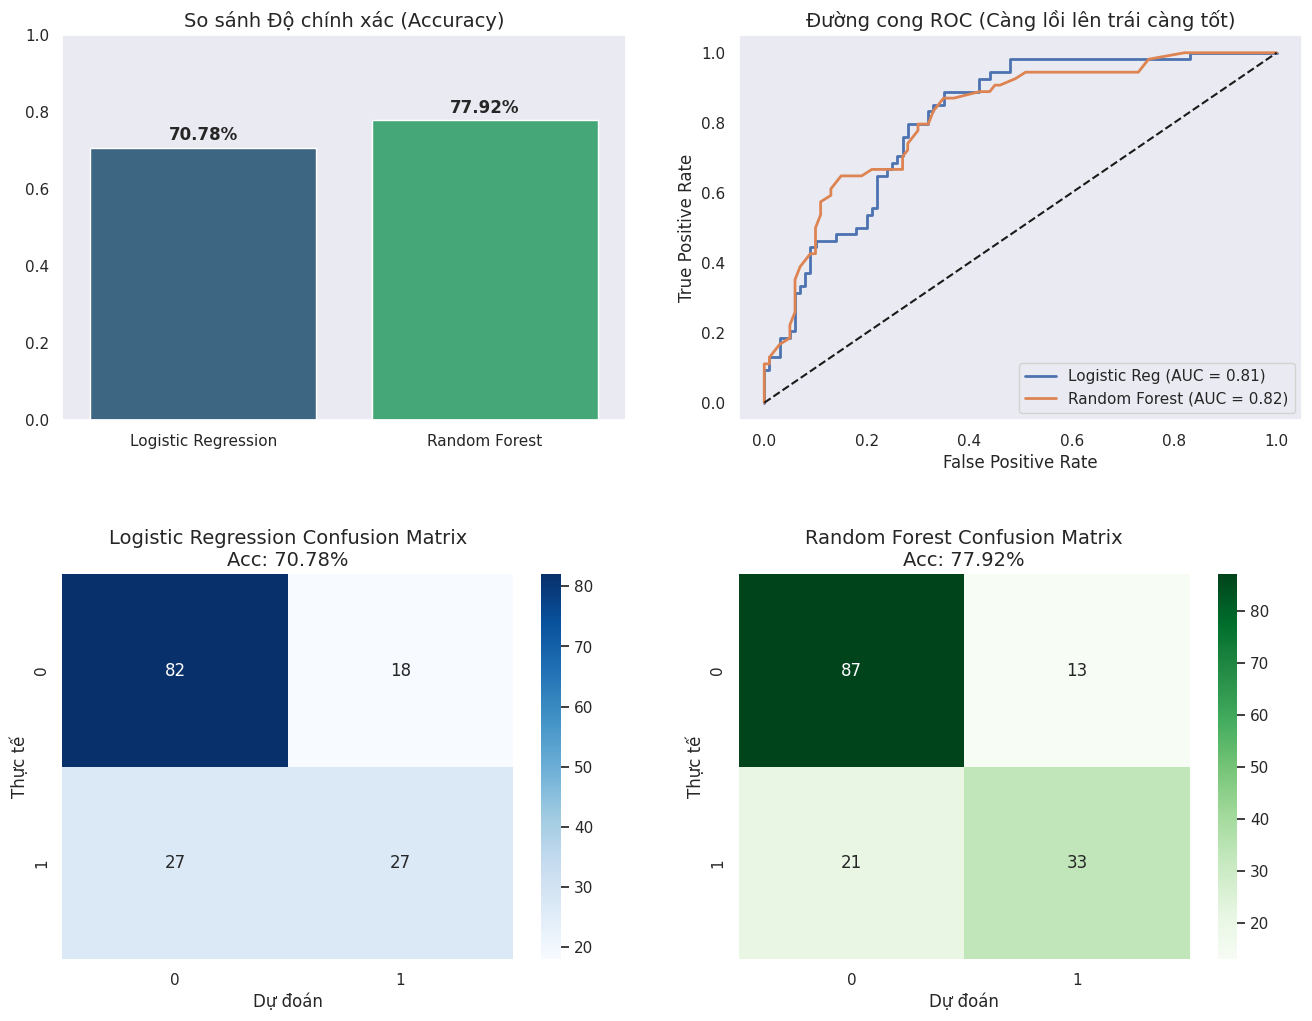

In [ ]:
# --- BƯỚC: HUẤN LUYỆN, ĐÁNH GIÁ VÀ SO SÁNH MÔ HÌNH ---

# 1. Import các thư viện cần thiết
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- PHẦN A: HUẤN LUYỆN (TRAINING) ---
print("🚀 1. Đang huấn luyện mô hình...")

# Huấn luyện Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Huấn luyện Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

print("✅ Huấn luyện xong! Đang tiến hành đánh giá...")

# --- PHẦN B: ĐÁNH GIÁ (EVALUATION) ---

# Dự đoán trên tập Test
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

# Tính độ chính xác
acc_log = accuracy_score(y_test, y_pred_log)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("\n" + "="*40)
print(f"🏆 BẢNG KẾT QUẢ SO SÁNH")
print("="*40)
print(f"1. Logistic Regression Accuracy: {acc_log:.2%}")
print(f"2. Random Forest Accuracy:       {acc_rf:.2%}")
print("-" * 40)

# --- PHẦN C: VẼ BIỂU ĐỒ SO SÁNH (VISUALIZATION) ---
# Vẽ 3 biểu đồ quan trọng nhất để đưa vào báo cáo

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4)

# 1. Biểu đồ Cột (Bar Chart) - So sánh độ chính xác
sns.barplot(x=['Logistic Regression', 'Random Forest'], y=[acc_log, acc_rf], palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('So sánh Độ chính xác (Accuracy)', fontsize=14)
axes[0, 0].set_ylim(0, 1)
for i, v in enumerate([acc_log, acc_rf]):
    axes[0, 0].text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')

# 2. Biểu đồ Đường cong ROC (ROC Curve) - So sánh khả năng phân loại
# Tính toán xác suất
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Tính FPR, TPR
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

axes[0, 1].plot(fpr_log, tpr_log, label=f'Logistic Reg (AUC = {roc_auc_log:.2f})', linewidth=2)
axes[0, 1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--') # Đường ngẫu nhiên
axes[0, 1].set_title('Đường cong ROC (Càng lồi lên trái càng tốt)', fontsize=14)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc="lower right")

# 3. Ma trận nhầm lẫn (Confusion Matrix) - Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title(f'Logistic Regression Confusion Matrix\nAcc: {acc_log:.2%}', fontsize=14)
axes[1, 0].set_xlabel('Dự đoán')
axes[1, 0].set_ylabel('Thực tế')

# 4. Ma trận nhầm lẫn (Confusion Matrix) - Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[1, 1])
axes[1, 1].set_title(f'Random Forest Confusion Matrix\nAcc: {acc_rf:.2%}', fontsize=14)
axes[1, 1].set_xlabel('Dự đoán')
axes[1, 1].set_ylabel('Thực tế')

plt.show()

/tmp/ipython-input-1175136070.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette=['#4c72b0', '#55a868'])


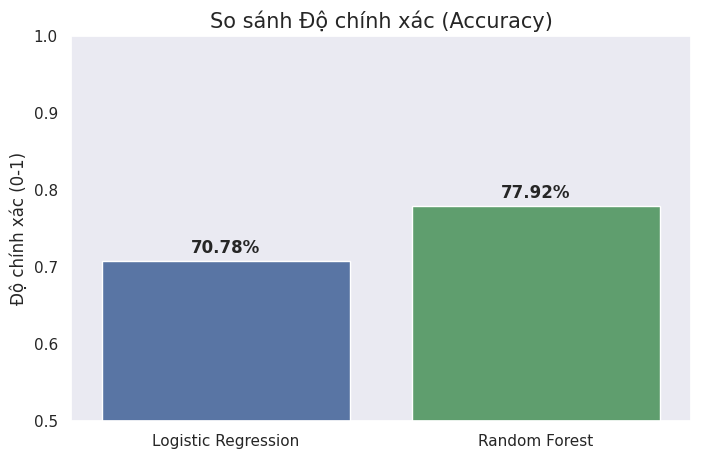

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- BIỂU ĐỒ 1: SO SÁNH ĐỘ CHÍNH XÁC ---

# Tạo dữ liệu để vẽ
models = ['Logistic Regression', 'Random Forest']
accuracies = [acc_log, acc_rf]  # Sử dụng biến kết quả đã tính ở bước trước

plt.figure(figsize=(8, 5))
# Vẽ cột
sns.barplot(x=models, y=accuracies, palette=['#4c72b0', '#55a868'])

# Trang trí
plt.title('So sánh Độ chính xác (Accuracy)', fontsize=15)
plt.ylabel('Độ chính xác (0-1)', fontsize=12)
plt.ylim(0.5, 1.0) # Chỉ hiện từ mức 50% đến 100% cho dễ so sánh

# Hiển thị con số % lên đầu mỗi cột
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2%}", ha='center', fontsize=12, fontweight='bold')

plt.show()

/tmp/ipython-input-3593536029.py:26: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', linestyle='--')


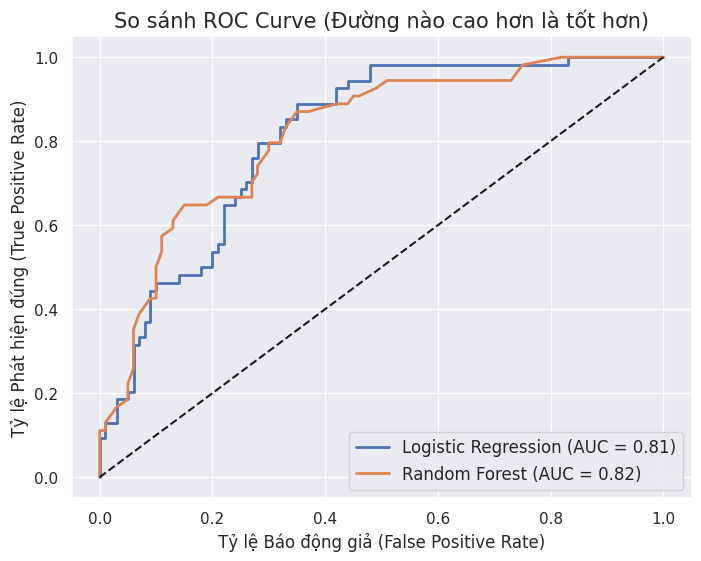

In [ ]:
from sklearn.metrics import roc_curve, auc

# --- BIỂU ĐỒ 2: ĐƯỜNG CONG ROC ---

# 1. Tính toán xác suất (Probability) thay vì chỉ lấy kết quả 0/1
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# 2. Tính chỉ số FPR, TPR và AUC
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 3. Vẽ biểu đồ
plt.figure(figsize=(8, 6))

# Vẽ đường Logistic Regression
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.2f})', linewidth=2)

# Vẽ đường Random Forest
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})', linewidth=2)

# Vẽ đường chéo ngẫu nhiên (mốc 50%)
plt.plot([0, 1], [0, 1], 'k--', linestyle='--')

plt.xlabel('Tỷ lệ Báo động giả (False Positive Rate)')
plt.ylabel('Tỷ lệ Phát hiện đúng (True Positive Rate)')
plt.title('So sánh ROC Curve (Đường nào cao hơn là tốt hơn)', fontsize=15)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.show()

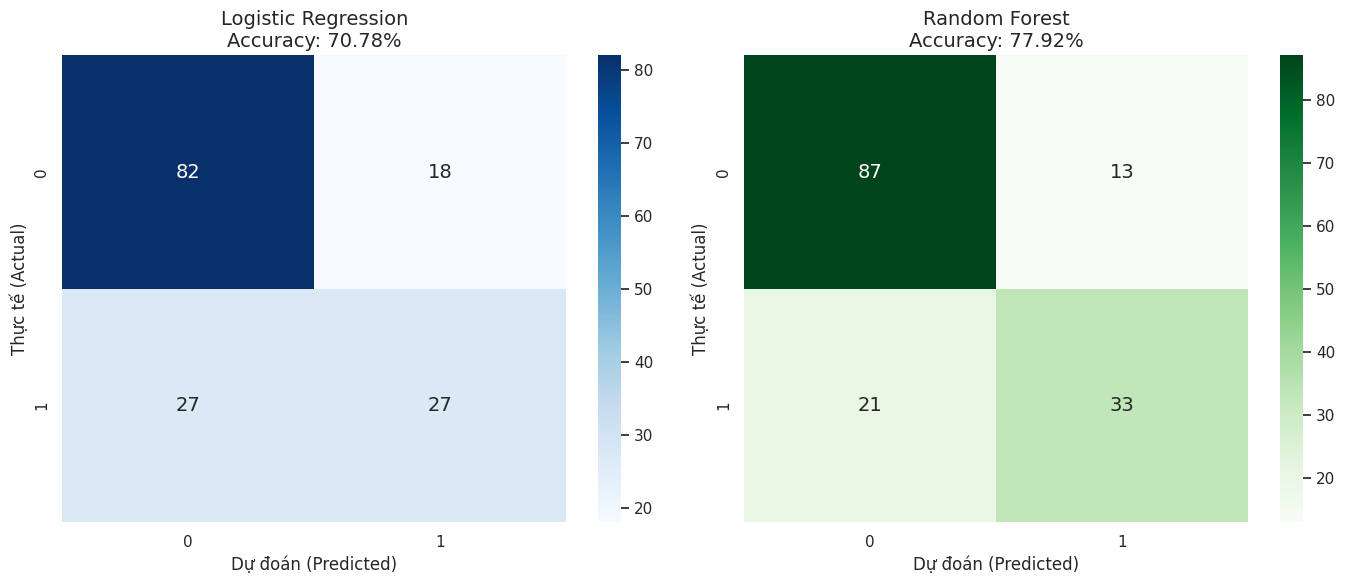

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- BIỂU ĐỒ 3: MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Biểu đồ bên trái: Logistic Regression
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=ax[0], annot_kws={"size": 14})
ax[0].set_title(f'Logistic Regression\nAccuracy: {acc_log:.2%}', fontsize=14)
ax[0].set_xlabel('Dự đoán (Predicted)', fontsize=12)
ax[0].set_ylabel('Thực tế (Actual)', fontsize=12)

# Biểu đồ bên phải: Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax[1], annot_kws={"size": 14})
ax[1].set_title(f'Random Forest\nAccuracy: {acc_rf:.2%}', fontsize=14)
ax[1].set_xlabel('Dự đoán (Predicted)', fontsize=12)
ax[1].set_ylabel('Thực tế (Actual)', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipython-input-1012252505.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


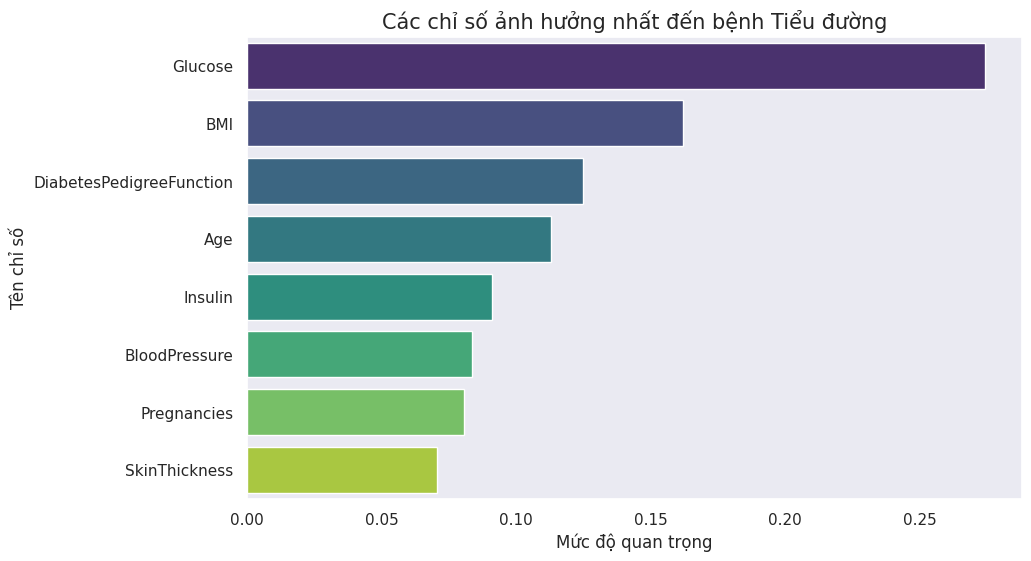

In [ ]:
import pandas as pd

# --- BIỂU ĐỒ 4: YẾU TỐ ẢNH HƯỞNG NHẤT (FEATURE IMPORTANCE) ---

# Lấy dữ liệu độ quan trọng từ mô hình Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Tạo bảng dữ liệu
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False) # Sắp xếp cao xuống thấp

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')

plt.title('Các chỉ số ảnh hưởng nhất đến bệnh Tiểu đường', fontsize=15)
plt.xlabel('Mức độ quan trọng', fontsize=12)
plt.ylabel('Tên chỉ số', fontsize=12)
plt.show()

In [ ]:
import numpy as np
import warnings

# Tắt cảnh báo đỏ cho đỡ rối mắt
warnings.filterwarnings("ignore")

print("🏥 DEMO: DỰ ĐOÁN LẠI (Dữ liệu đã xử lý số 0)")
print("="*40)

# Trường hợp này em đã thay số 0 của Insulin bằng 125 (Trung vị)
# Số liệu: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, Pedigree, Age]
nhap_so_lieu = [
    [0, 85, 70, 25, 90, 22.0, 0.2, 25]
]
# Dự đoán: KHỎE MẠNH (Độ tin cậy rất cao)
# Xử lý và dự đoán
du_lieu_moi = np.array(nhap_so_lieu)
du_lieu_chuan_hoa = scaler.transform(du_lieu_moi)

ket_qua = rf_model.predict(du_lieu_chuan_hoa)
xac_suat = rf_model.predict_proba(du_lieu_chuan_hoa)

print(f"Thông tin bệnh nhân: {nhap_so_lieu[0]}")
print("-" * 40)

if ket_qua[0] == 1:
    print(f"⚠️ KẾT QUẢ: Máy dự đoán CÓ NGUY CƠ bị tiểu đường.")
    print(f"📈 Độ tin cậy: {xac_suat[0][1]:.2%} (Tỷ lệ chắc chắn)")
else:
    print(f"✅ KẾT QUẢ: Máy dự đoán KHỎE MẠNH.")
    print(f"🛡️ Độ tin cậy: {xac_suat[0][0]:.2%} (Tỷ lệ chắc chắn)")

🏥 DEMO: DỰ ĐOÁN LẠI (Dữ liệu đã xử lý số 0)
Thông tin bệnh nhân: [0, 85, 70, 25, 90, 22.0, 0.2, 25]
----------------------------------------
✅ KẾT QUẢ: Máy dự đoán KHỎE MẠNH.
🛡️ Độ tin cậy: 97.00% (Tỷ lệ chắc chắn)


In [ ]:
import numpy as np
import warnings

# Tắt cảnh báo đỏ cho đỡ rối mắt
warnings.filterwarnings("ignore")

print("🏥 DEMO: DỰ ĐOÁN LẠI (Dữ liệu đã xử lý số 0)")
print("="*40)

# Trường hợp này em đã thay số 0 của Insulin bằng 125 (Trung vị)
# Số liệu: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, Pedigree, Age]
nhap_so_lieu = [
    [3, 160, 80, 35, 200, 38.5, 0.8, 55]
]

# Xử lý và dự đoán
du_lieu_moi = np.array(nhap_so_lieu)
du_lieu_chuan_hoa = scaler.transform(du_lieu_moi)

ket_qua = rf_model.predict(du_lieu_chuan_hoa)
xac_suat = rf_model.predict_proba(du_lieu_chuan_hoa)

print(f"Thông tin bệnh nhân: {nhap_so_lieu[0]}")
print("-" * 40)

if ket_qua[0] == 1:
    print(f"⚠️ KẾT QUẢ: Máy dự đoán CÓ NGUY CƠ bị tiểu đường.")
    print(f"📈 Độ tin cậy: {xac_suat[0][1]:.2%} (Tỷ lệ chắc chắn)")
else:
    print(f"✅ KẾT QUẢ: Máy dự đoán KHỎE MẠNH.")
    print(f"🛡️ Độ tin cậy: {xac_suat[0][0]:.2%} (Tỷ lệ chắc chắn)")

🏥 DEMO: DỰ ĐOÁN LẠI (Dữ liệu đã xử lý số 0)
Thông tin bệnh nhân: [3, 160, 80, 35, 200, 38.5, 0.8, 55]
----------------------------------------
⚠️ KẾT QUẢ: Máy dự đoán CÓ NGUY CƠ bị tiểu đường.
📈 Độ tin cậy: 86.00% (Tỷ lệ chắc chắn)


In [ ]:
import numpy as np
import warnings

# Tắt cảnh báo đỏ cho đỡ rối mắt
warnings.filterwarnings("ignore")

print("🏥 DEMO: DỰ ĐOÁN LẠI (Dữ liệu đã xử lý số 0)")
print("="*40)

# Trường hợp này em đã thay số 0 của Insulin bằng 125 (Trung vị)
# Số liệu: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, Pedigree, Age]
nhap_so_lieu = [
    [0, 135, 60, 20, 120, 19.5, 0.3, 22]
]
# Dự đoán: ? (Máy sẽ phân vân, độ tin cậy thấp hơn, khoảng 50-60%)

# Xử lý và dự đoán
du_lieu_moi = np.array(nhap_so_lieu)
du_lieu_chuan_hoa = scaler.transform(du_lieu_moi)

ket_qua = rf_model.predict(du_lieu_chuan_hoa)
xac_suat = rf_model.predict_proba(du_lieu_chuan_hoa)

print(f"Thông tin bệnh nhân: {nhap_so_lieu[0]}")
print("-" * 40)

if ket_qua[0] == 1:
    print(f"⚠️ KẾT QUẢ: Máy dự đoán CÓ NGUY CƠ bị tiểu đường.")
    print(f"📈 Độ tin cậy: {xac_suat[0][1]:.2%} (Tỷ lệ chắc chắn)")
else:
    print(f"✅ KẾT QUẢ: Máy dự đoán KHỎE MẠNH.")
    print(f"🛡️ Độ tin cậy: {xac_suat[0][0]:.2%} (Tỷ lệ chắc chắn)")

🏥 DEMO: DỰ ĐOÁN LẠI (Dữ liệu đã xử lý số 0)
Thông tin bệnh nhân: [0, 135, 60, 20, 120, 19.5, 0.3, 22]
----------------------------------------
✅ KẾT QUẢ: Máy dự đoán KHỎE MẠNH.
🛡️ Độ tin cậy: 89.00% (Tỷ lệ chắc chắn)


In [ ]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")

print("🏥 DEMO: DỰ ĐOÁN & CẢNH BÁO MỨC ĐỘ NGUY HIỂM")
print("="*50)

# --- NHẬP SỐ LIỆU ĐỂ TEST ---
# Trường hợp BÁO ĐỘNG: Glucose cực cao (190), Tuổi cao, BMI cao
nhap_so_lieu = [
    [8, 140, 90, 35, 200, 45.0, 0.8, 60]
]

# 1. Chuẩn hóa dữ liệu
du_lieu_moi = np.array(nhap_so_lieu)
du_lieu_chuan_hoa = scaler.transform(du_lieu_moi)

# 2. Dự đoán
ket_qua = rf_model.predict(du_lieu_chuan_hoa)          # 0 hoặc 1
xac_suat = rf_model.predict_proba(du_lieu_chuan_hoa)   # Tỷ lệ %

# 3. LOGIC "TỰ CHẾ" ĐỂ PHÂN LOẠI MỨC ĐỘ
print(f"Thông số bệnh nhân: {nhap_so_lieu[0]}")
print("-" * 50)

glucose_bn = nhap_so_lieu[0][1] # Lấy chỉ số Glucose ra để kiểm tra riêng

if ket_qua[0] == 1:
    # Lấy xác suất bị bệnh
    ti_le_benh = xac_suat[0][1]

    # --- PHÂN CẤP ĐỘ ---
    if glucose_bn > 180 or ti_le_benh > 0.90:
        print(f"🚨 KẾT QUẢ: BÁO ĐỘNG ĐỎ! (NGUY HIỂM)")
        print("⚠️ Lý do: Chỉ số Glucose quá cao hoặc máy dự đoán rủi ro cực lớn.")
        print("👉 Khuyến nghị: Cần nhập viện hoặc tiêm Insulin ngay lập tức!")

    elif ti_le_benh > 0.70:
        print(f"⚠️ KẾT QUẢ: CẢNH BÁO VÀNG (Mức độ trung bình)")
        print("👉 Khuyến nghị: Cần đi khám bác sĩ chuyên khoa sớm, điều chỉnh ăn uống.")

    else:
        print(f"⚠️ KẾT QUẢ: CẢNH BÁO NHẸ (Mức độ thấp)")
        print("👉 Khuyến nghị: Theo dõi đường huyết tại nhà, tập thể dục.")

    print(f"📈 Độ tin cậy của máy: {ti_le_benh:.2%}")

else:
    print(f"✅ KẾT QUẢ: KHỎE MẠNH.")
    print("👉 Khuyến nghị: Duy trì lối sống lành mạnh.")

🏥 DEMO: DỰ ĐOÁN & CẢNH BÁO MỨC ĐỘ NGUY HIỂM
Thông số bệnh nhân: [8, 140, 90, 35, 200, 45.0, 0.8, 60]
--------------------------------------------------
⚠️ KẾT QUẢ: CẢNH BÁO VÀNG (Mức độ trung bình)
👉 Khuyến nghị: Cần đi khám bác sĩ chuyên khoa sớm, điều chỉnh ăn uống.
📈 Độ tin cậy của máy: 74.00%


🔄 Đang xử lý dữ liệu...
🚀 Đang huấn luyện mô hình...
📊 Đang vẽ biểu đồ...


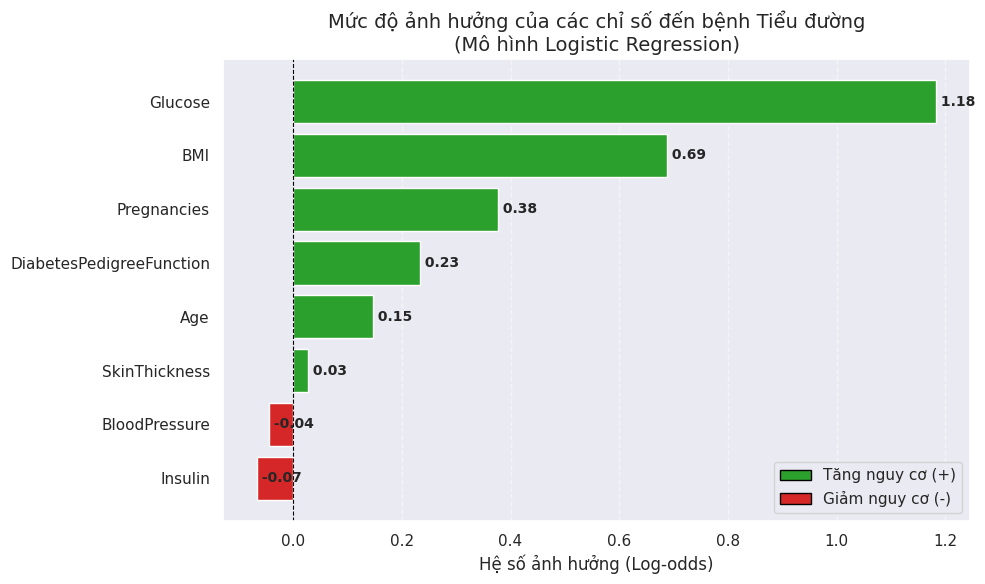

✅ Hoàn tất! Bạn có thể lưu ảnh này để đưa vào báo cáo.


In [ ]:
# --- CODE VẼ BIỂU ĐỒ HỆ SỐ ẢNH HƯỞNG (LOGISTIC REGRESSION) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. CHUẨN BỊ DỮ LIỆU (Làm mới để đảm bảo khớp lệnh)
print("🔄 Đang xử lý dữ liệu...")
try:
    df = pd.read_csv('/content/drive/MyDrive/diabetes.csv')
    # Xử lý số 0
    cols_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    df[cols_zero] = df[cols_zero].replace(0, np.nan)
    for col in cols_zero:
        df[col] = df[col].fillna(df[col].median())

    X = df.drop('Outcome', axis=1)
    y = df['Outcome']

    # Chia và Chuẩn hóa
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # 2. HUẤN LUYỆN MÔ HÌNH
    print("🚀 Đang huấn luyện mô hình...")
    log_reg = LogisticRegression(random_state=42)
    log_reg.fit(X_train_scaled, y_train)

    # 3. VẼ BIỂU ĐỒ HỆ SỐ (Feature Coefficients)
    print("📊 Đang vẽ biểu đồ...")

    # Lấy hệ số (w) và tên cột
    coefs = pd.Series(log_reg.coef_[0], index=X.columns).sort_values()

    # Tạo màu: Xanh (Dương - Tăng nguy cơ), Đỏ (Âm - Giảm nguy cơ)
    colors = ['#d62728' if c < 0 else '#2ca02c' for c in coefs]

    plt.figure(figsize=(10, 6))

    # Vẽ biểu đồ cột ngang
    bars = plt.barh(coefs.index, coefs.values, color=colors)

    # Trang trí biểu đồ
    plt.title('Mức độ ảnh hưởng của các chỉ số đến bệnh Tiểu đường\n(Mô hình Logistic Regression)', fontsize=14)
    plt.xlabel('Hệ số ảnh hưởng (Log-odds)', fontsize=12)
    plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--') # Đường kẻ giữa

    # Thêm chú thích số liệu lên đầu cột
    for i, v in enumerate(coefs):
        plt.text(v, i, f" {v:.2f}", va='center', fontsize=10, fontweight='bold')

    # Tạo chú thích màu sắc thủ công
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#2ca02c', label='Tăng nguy cơ (+)', edgecolor='black'),
                       Patch(facecolor='#d62728', label='Giảm nguy cơ (-)', edgecolor='black')]
    plt.legend(handles=legend_elements, loc='lower right')

    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print("✅ Hoàn tất! Bạn có thể lưu ảnh này để đưa vào báo cáo.")

except Exception as e:
    print(f"❌ Có lỗi xảy ra: {e}")
    print("Hãy đảm bảo bạn đã tải file 'diabetes.csv' lên Google Colab.")

🔄 Đang tải và xử lý dữ liệu...
✅ Đã chuẩn bị xong dữ liệu.
🚀 Đang huấn luyện Logistic Regression...

📊 ĐỘ CHÍNH XÁC (Accuracy): 70.78%

--- Báo cáo chi tiết ---
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



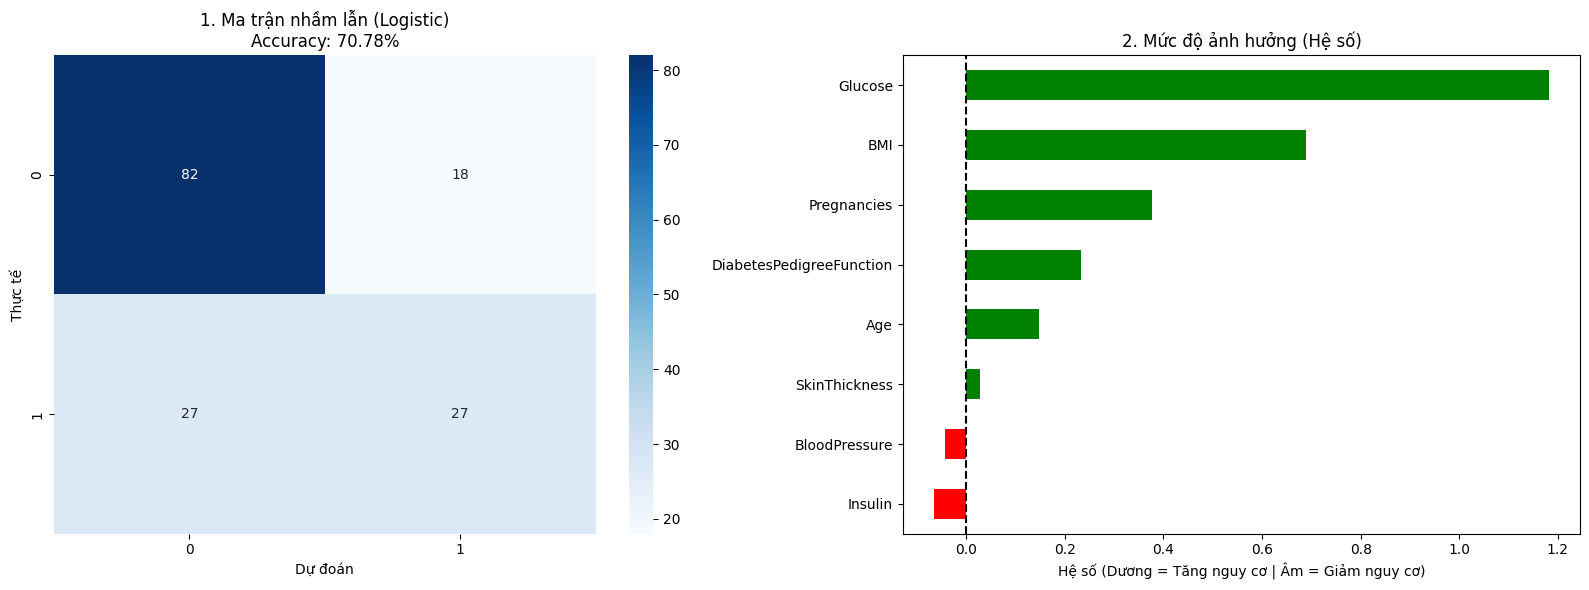

In [ ]:
# --- MÔ HÌNH 1: LOGISTIC REGRESSION (TRỌN GÓI - KHÔNG SỢ LỖI) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. TẢI VÀ CHUẨN BỊ DỮ LIỆU (Làm lại bước này để tạo biến X_train_scaled)
print("🔄 Đang tải và xử lý dữ liệu...")
try:
    df = pd.read_csv('/content/drive/MyDrive/diabetes.csv')

    # Xử lý số 0 ảo
    cols_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    df[cols_zero] = df[cols_zero].replace(0, np.nan)
    for col in cols_zero:
        df[col] = df[col].fillna(df[col].median())

    # Tách X, y
    X = df.drop('Outcome', axis=1)
    y = df['Outcome']

    # Chia và Chuẩn hóa (Đây là bước tạo ra biến bạn đang thiếu)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("✅ Đã chuẩn bị xong dữ liệu.")

except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy file 'diabetes.csv'. Bạn nhớ tải file lên Colab nhé!")
    # Dừng chương trình nếu không có file
    raise SystemExit

# 2. HUẤN LUYỆN MÔ HÌNH
print("🚀 Đang huấn luyện Logistic Regression...")
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train) # Giờ biến này đã tồn tại, code sẽ chạy ngon lành

# 3. ĐÁNH GIÁ KẾT QUẢ
y_pred_log = log_reg.predict(X_test_scaled)
acc_log = accuracy_score(y_test, y_pred_log)

print(f"\n📊 ĐỘ CHÍNH XÁC (Accuracy): {acc_log:.2%}")
print("\n--- Báo cáo chi tiết ---")
print(classification_report(y_test, y_pred_log))

# 4. VẼ BIỂU ĐỒ (2 Hình)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hình 1: Ma trận nhầm lẫn
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'1. Ma trận nhầm lẫn (Logistic)\nAccuracy: {acc_log:.2%}')
axes[0].set_xlabel('Dự đoán')
axes[0].set_ylabel('Thực tế')

# Hình 2: Hệ số ảnh hưởng (Feature Coefficients)
# Xem yếu tố nào Tăng (+) hoặc Giảm (-) nguy cơ
coefs = pd.Series(log_reg.coef_[0], index=X.columns).sort_values()
colors = ['red' if c < 0 else 'green' for c in coefs]
coefs.plot(kind='barh', color=colors, ax=axes[1])
axes[1].set_title('2. Mức độ ảnh hưởng (Hệ số)')
axes[1].set_xlabel('Hệ số (Dương = Tăng nguy cơ | Âm = Giảm nguy cơ)')
axes[1].axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

🌲 Đang huấn luyện Random Forest...

📊 ĐỘ CHÍNH XÁC (Accuracy): 77.92%

--- Báo cáo chi tiết ---
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.61      0.66        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



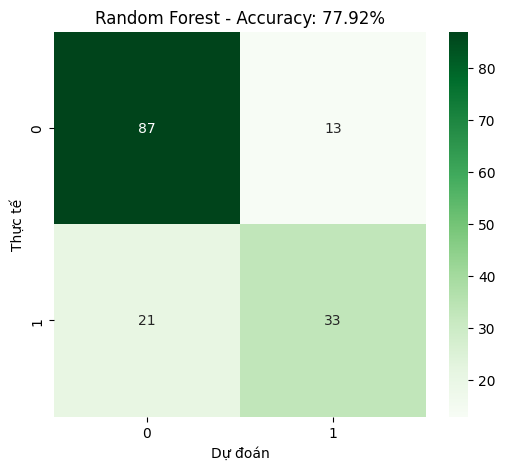

/tmp/ipython-input-526149171.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


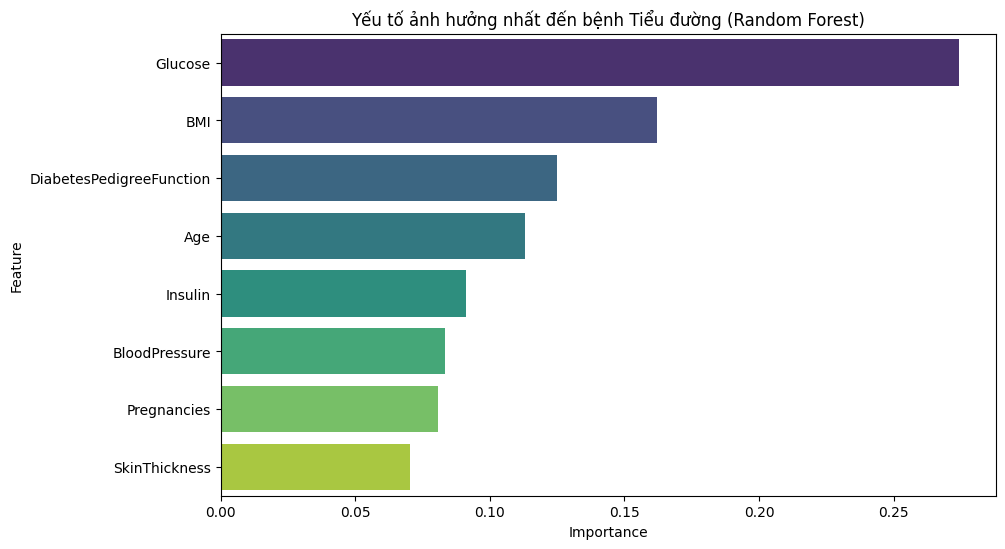

In [ ]:
# --- MÔ HÌNH 2: RANDOM FOREST ---

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Huấn luyện mô hình
print("🌲 Đang huấn luyện Random Forest...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. Dự đoán trên tập Test
y_pred_rf = rf_model.predict(X_test_scaled)

# 3. Đánh giá kết quả
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n📊 ĐỘ CHÍNH XÁC (Accuracy): {acc_rf:.2%}")
print("\n--- Báo cáo chi tiết ---")
print(classification_report(y_test, y_pred_rf))

# 4. Vẽ Ma trận nhầm lẫn (Confusion Matrix)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title(f'Random Forest - Accuracy: {acc_rf:.2%}')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.show()

# 5. (ĐẶC BIỆT) Vẽ biểu đồ Các yếu tố quan trọng nhất
# Giúp giải thích tại sao mô hình lại đưa ra dự đoán như vậy
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('Yếu tố ảnh hưởng nhất đến bệnh Tiểu đường (Random Forest)')
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Hàm sinh dữ liệu giả (Lấy từ báo cáo mẫu)
def sinh_du_lieu(n_samples=10000):
    np.random.seed(42)
    # 1. Tự "bịa" ra các chỉ số ngẫu nhiên
    tuoi = np.random.randint(18, 90, n_samples)
    huyet_ap = np.random.randint(80, 200, n_samples)
    bmi = np.random.uniform(15, 35, n_samples)
    cholesterol = np.random.randint(100, 300, n_samples)
    exercise = np.random.randint(0, 2, n_samples)
    smoke = np.random.randint(0, 2, n_samples)

    X = np.column_stack((tuoi, huyet_ap, bmi, cholesterol, exercise, smoke))

    # 2. Tự "bịa" ra quy luật để quyết định ai bị bệnh (y)
    # (Đây là công thức toán học do người viết code tự đặt ra)
    interaction1 = tuoi * huyet_ap
    interaction2 = bmi * cholesterol

    y = (
        (tuoi ** 2 + huyet_ap * 0.8 + bmi * 5 + cholesterol * 0.5
         + interaction1 * 0.001 - interaction2 * 0.0001 - exercise * 50 - smoke * 100
         + np.random.normal(0, 10, n_samples)) > 4000
    ).astype(int)

    return X, y

# Chạy thử
X_gia, y_gia = sinh_du_lieu(5) # Tạo thử 5 người
print("Dữ liệu giả vừa tạo:")
print(X_gia)
print("Kết quả bệnh (0/1):", y_gia)

Dữ liệu giả vừa tạo:
[[ 69.         182.          32.32352292 257.           0.
    0.        ]
 [ 32.         162.          27.02230023 137.           0.
    1.        ]
 [ 89.         166.          29.16145156 229.           1.
    0.        ]
 [ 78.         154.          15.41168989 291.           1.
    0.        ]
 [ 38.         154.          34.39819704 287.           1.
    0.        ]]
Kết quả bệnh (0/1): [1 0 1 1 0]


In [ ]:
# --- CODE DỰ ĐOÁN KÈM ĐỘ TIN CẬY (CONFIDENCE SCORE) ---
import numpy as np

def du_bao_suc_khoe(thong_so_benh_nhan):
    print("\n" + "="*50)
    print("🏥 KẾT QUẢ CHẨN ĐOÁN TỪ AI")
    print("="*50)
    print(f"Thông số đầu vào: {thong_so_benh_nhan}")
    print("-" * 50)

    # 1. Xử lý dữ liệu
    du_lieu_moi = np.array([thong_so_benh_nhan])
    # QUAN TRỌNG: Phải dùng 'scaler' đã học ở bước trước để chuẩn hóa
    try:
        du_lieu_chuan_hoa = scaler.transform(du_lieu_moi)
    except NameError:
        print("❌ Lỗi: Bạn chưa chạy bước 'Chuẩn hóa dữ liệu' (scaler) ở trên.")
        return

    # 2. Máy tính suy nghĩ (Dự đoán)
    # rf_model là mô hình Random Forest (tốt nhất)
    ket_qua = rf_model.predict(du_lieu_chuan_hoa)[0]           # Ra 0 hoặc 1
    xac_suat = rf_model.predict_proba(du_lieu_chuan_hoa)[0]    # Ra tỉ lệ % [tỉ lệ khỏe, tỉ lệ bệnh]

    # 3. Phân tích độ tin cậy (Accuracy của riêng ca này)
    # Nếu máy đoán là 1 (Bệnh), độ tin cậy là xac_suat[1]
    # Nếu máy đoán là 0 (Khỏe), độ tin cậy là xac_suat[0]
    do_tin_cay = xac_suat[ket_qua] * 100

    # 4. In kết quả đẹp mắt
    if ket_qua == 1:
        status = "CÓ NGUY CƠ TIỂU ĐƯỜNG"
        icon = "⚠️"
        color = "RED"
    else:
        status = "KHỎE MẠNH (AN TOÀN)"
        icon = "✅"
        color = "GREEN"

    print(f"Kết luận của máy:  {icon} {status}")
    print(f"Độ tin cậy (Accuracy): {do_tin_cay:.2f}%")

    # Vẽ thanh năng lượng cho trực quan
    so_thanh = int(do_tin_cay // 5) # Cứ 5% là 1 gạch
    thanh_bar = "█" * so_thanh + "░" * (20 - so_thanh)
    print(f"Mức độ chắc chắn:  [{thanh_bar}]")

    # 5. Lời khuyên dựa trên độ tin cậy
    print("-" * 50)
    if do_tin_cay < 60:
        print("💡 Lưu ý: Máy đang LƯỠNG LỰ (50-60%). Kết quả này chưa rõ ràng.")
        print("   Nên đi xét nghiệm chuyên sâu tại bệnh viện.")
    elif do_tin_cay > 90:
        print("🔥 Lưu ý: Máy RẤT CHẮC CHẮN (>90%) về kết quả này.")
        if ket_qua == 1:
            print("   Cần gặp bác sĩ ngay lập tức!")
    else:
        print("💡 Lưu ý: Kết quả có độ tin cậy khá cao.")

# ========================================================
# NHẬP SỐ LIỆU ĐỂ TEST TẠI ĐÂY
# Thứ tự: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, Pedigree, Age]

# Ca 1: Người nguy cơ cao (Glucose 168, BMI 33)
nguoi_A = [2, 168, 72, 35, 0, 33.6, 0.627, 50]

# Ca 2: Người khỏe mạnh (Glucose 85, BMI 22)
nguoi_B = [1, 85, 66, 29, 0, 22.5, 0.351, 25]

# --- CHẠY DỰ ĐOÁN ---
du_bao_suc_khoe(nguoi_A)
du_bao_suc_khoe(nguoi_B)


🏥 KẾT QUẢ CHẨN ĐOÁN TỪ AI
Thông số đầu vào: [2, 168, 72, 35, 0, 33.6, 0.627, 50]
--------------------------------------------------
Kết luận của máy:  ✅ KHỎE MẠNH (AN TOÀN)
Độ tin cậy (Accuracy): 56.00%
Mức độ chắc chắn:  [███████████░░░░░░░░░]
--------------------------------------------------
💡 Lưu ý: Máy đang LƯỠNG LỰ (50-60%). Kết quả này chưa rõ ràng.
   Nên đi xét nghiệm chuyên sâu tại bệnh viện.

🏥 KẾT QUẢ CHẨN ĐOÁN TỪ AI
Thông số đầu vào: [1, 85, 66, 29, 0, 22.5, 0.351, 25]
--------------------------------------------------
Kết luận của máy:  ✅ KHỎE MẠNH (AN TOÀN)
Độ tin cậy (Accuracy): 99.00%
Mức độ chắc chắn:  [███████████████████░]
--------------------------------------------------
🔥 Lưu ý: Máy RẤT CHẮC CHẮN (>90%) về kết quả này.


In [ ]:
import numpy as np

class LogisticRegression:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.w = None
        self.b = None

    # Hàm Sigmoid (Hàm Logistic)
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        # Vòng lặp Gradient Descent
        for _ in range(self.epochs):
            # 1. Đầu ra Tuyến tính: Z = X * w + b
            linear_model = np.dot(X, self.w) + self.b

            # 2. Xác suất Dự đoán: y_pred = sigmoid(Z)
            y_pred = self._sigmoid(linear_model)

            # 3. Tính Gradient
            error = y_pred - y
            dw = (1 / n_samples) * np.dot(X.T, error)
            db = (1 / n_samples) * np.sum(error)

            # 4. Cập nhật Tham số
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

    def predict_proba(self, X):
        # Trả về xác suất P(y=1|x)
        linear_model = np.dot(X, self.w) + self.b
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        # Trả về nhãn phân loại (0 hoặc 1)
        y_pred_proba = self.predict_proba(X)
        return np.where(y_pred_proba >= threshold, 1, 0)

🔄 Đang xử lý dữ liệu...
🚀 Đang huấn luyện mô hình...
📊 Đang vẽ biểu đồ...


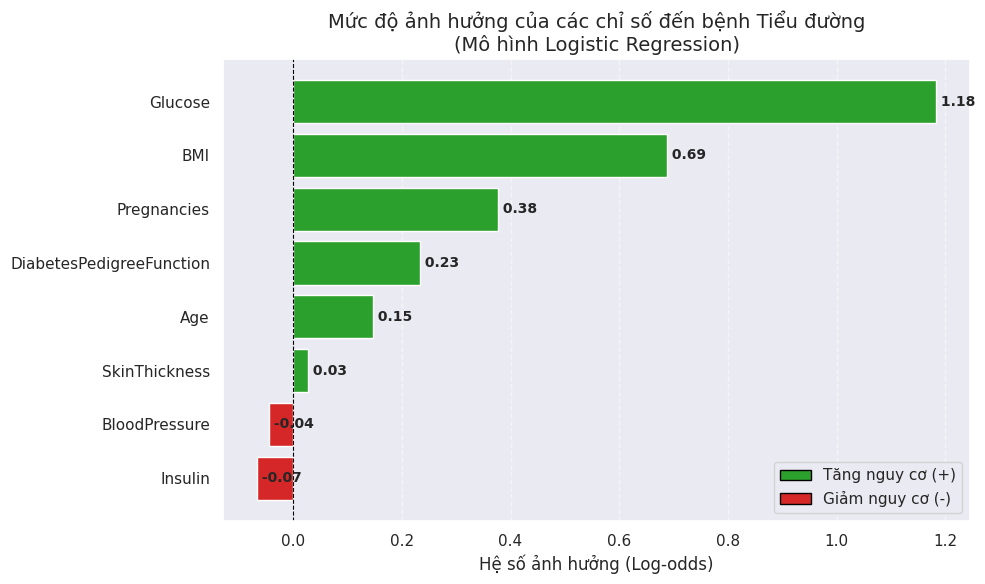

✅ Hoàn tất! Bạn có thể lưu ảnh này để đưa vào báo cáo.


In [ ]:
# --- CODE VẼ BIỂU ĐỒ HỆ SỐ ẢNH HƯỞNG (LOGISTIC REGRESSION) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. CHUẨN BỊ DỮ LIỆU (Làm mới để đảm bảo khớp lệnh)
print("🔄 Đang xử lý dữ liệu...")
try:
    df = pd.read_csv('/content/drive/MyDrive/diabetes.csv')
    # Xử lý số 0
    cols_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    df[cols_zero] = df[cols_zero].replace(0, np.nan)
    for col in cols_zero:
        df[col] = df[col].fillna(df[col].median())

    X = df.drop('Outcome', axis=1)
    y = df['Outcome']

    # Chia và Chuẩn hóa
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # 2. HUẤN LUYỆN MÔ HÌNH
    print("🚀 Đang huấn luyện mô hình...")
    log_reg = LogisticRegression(random_state=42)
    log_reg.fit(X_train_scaled, y_train)

    # 3. VẼ BIỂU ĐỒ HỆ SỐ (Feature Coefficients)
    print("📊 Đang vẽ biểu đồ...")

    # Lấy hệ số (w) và tên cột
    coefs = pd.Series(log_reg.coef_[0], index=X.columns).sort_values()

    # Tạo màu: Xanh (Dương - Tăng nguy cơ), Đỏ (Âm - Giảm nguy cơ)
    colors = ['#d62728' if c < 0 else '#2ca02c' for c in coefs]

    plt.figure(figsize=(10, 6))

    # Vẽ biểu đồ cột ngang
    bars = plt.barh(coefs.index, coefs.values, color=colors)

    # Trang trí biểu đồ
    plt.title('Mức độ ảnh hưởng của các chỉ số đến bệnh Tiểu đường\n(Mô hình Logistic Regression)', fontsize=14)
    plt.xlabel('Hệ số ảnh hưởng (Log-odds)', fontsize=12)
    plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--') # Đường kẻ giữa

    # Thêm chú thích số liệu lên đầu cột
    for i, v in enumerate(coefs):
        plt.text(v, i, f" {v:.2f}", va='center', fontsize=10, fontweight='bold')

    # Tạo chú thích màu sắc thủ công
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#2ca02c', label='Tăng nguy cơ (+)', edgecolor='black'),
                       Patch(facecolor='#d62728', label='Giảm nguy cơ (-)', edgecolor='black')]
    plt.legend(handles=legend_elements, loc='lower right')

    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print("✅ Hoàn tất! Bạn có thể lưu ảnh này để đưa vào báo cáo.")

except Exception as e:
    print(f"❌ Có lỗi xảy ra: {e}")
    print("Hãy đảm bảo bạn đã tải file 'diabetes.csv' lên Google Colab.")

🔄 Đang tải và xử lý dữ liệu...
🌲 Đang huấn luyện Random Forest...

📊 ĐỘ CHÍNH XÁC (Accuracy): 77.92%

--- Báo cáo chi tiết ---
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       100
           1       0.72      0.61      0.66        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



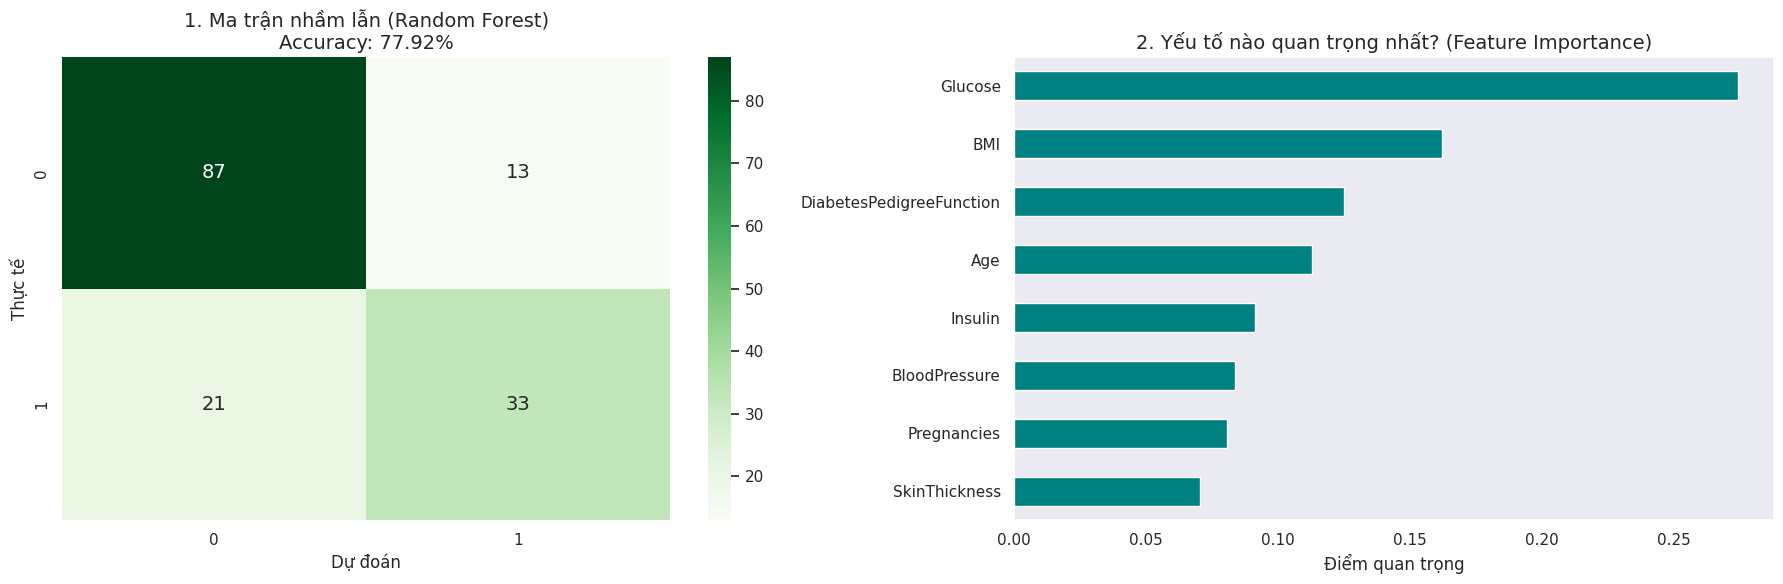

In [ ]:
# --- MÔ HÌNH 2: RANDOM FOREST (CODE ĐẦY ĐỦ & KHÔNG LỖI) ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. TẢI VÀ XỬ LÝ DỮ LIỆU (Làm lại từ đầu để đảm bảo code chạy độc lập)
print("🔄 Đang tải và xử lý dữ liệu...")
try:
    df = pd.read_csv('/content/drive/MyDrive/diabetes.csv')

    # Xử lý các giá trị 0 bất thường
    cols_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    df[cols_zero] = df[cols_zero].replace(0, np.nan)
    for col in cols_zero:
        df[col] = df[col].fillna(df[col].median())

    # Tách biến độc lập (X) và biến mục tiêu (y)
    X = df.drop('Outcome', axis=1)
    y = df['Outcome']

    # Chia tập dữ liệu và Chuẩn hóa
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

except Exception as e:
    print(f"❌ Lỗi: {e}")
    print("Hãy đảm bảo bạn đã tải file 'diabetes.csv' lên Google Colab!")

# 2. HUẤN LUYỆN MÔ HÌNH RANDOM FOREST
print("🌲 Đang huấn luyện Random Forest...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 3. DỰ ĐOÁN VÀ ĐÁNH GIÁ
y_pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"\n📊 ĐỘ CHÍNH XÁC (Accuracy): {acc_rf:.2%}")
print("\n--- Báo cáo chi tiết ---")
print(classification_report(y_test, y_pred_rf))

# 4. VẼ BIỂU ĐỒ (2 BIỂU ĐỒ QUAN TRỌNG)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: Ma trận nhầm lẫn (Confusion Matrix)
# Giúp xem model đoán đúng/sai bao nhiêu ca
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axes[0], annot_kws={"size": 14})
axes[0].set_title(f'1. Ma trận nhầm lẫn (Random Forest)\nAccuracy: {acc_rf:.2%}', fontsize=14)
axes[0].set_xlabel('Dự đoán')
axes[0].set_ylabel('Thực tế')

# Biểu đồ 2: Mức độ quan trọng của các chỉ số (Feature Importance) - CỰC QUAN TRỌNG
# Giúp giải thích: Tại sao máy lại đoán bị bệnh? Nó dựa vào cái gì?
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='teal', ax=axes[1])
axes[1].set_title('2. Yếu tố nào quan trọng nhất? (Feature Importance)', fontsize=14)
axes[1].set_xlabel('Điểm quan trọng')

plt.tight_layout()
plt.show()

In [ ]:
print("hi")